# S&P 100 Monte Carlo

# Alexy Palkhouski alexypalkhouski2004@gmail.com

This notebook runs the mean-variance / Monte Carlo analysis on **S&P 100 stocks** pulled from **Yahoo Finance**.

# Exercises

**1. Data Loading & Cleaning (Yahoo Finance, S&P 100)**

Pull monthly total-return data for the S&P 100 constituents from Yahoo Finance with `yfinance`. For the risk-free rate we use the 13-week T-bill yield (`^IRX`), which Yahoo reports as an annualized percentage; we convert it to a daily rate.

Steps:
- Import `pandas`, `numpy`, `matplotlib`, `yfinance`.
- Download monthly adjusted prices for the S&P 100 tickers.
- Compute simple monthly returns (in percent, to match the scale used in the original assignment).
- Download `^IRX` and convert to a monthly risk-free rate (in percent).
- Build a dataframe of excess returns called `df`.
- Drop columns/rows with missing data so we have a clean balanced panel.
- Call `df.head()`.

In [2]:
!pip install -q yfinance

In [41]:
import numpy as np
import pandas as pd
import yfinance as yf

# 1. Define S&P 100 Tickers and Date Range
sp100 = [
    "AAPL","ABBV","ABT","ACN","ADBE","AIG","AMD","AMGN","AMT","AMZN",
    "AVGO","AXP","BA","BAC","BKNG","BLK","BMY","BRK-B","C",
    "CAT","CHTR","CL","CMCSA","COF","COP","COST","CRM","CSCO","CVS",
    "CVX","DE","DHR","DIS","DOW","DUK","EMR","F","FDX","GD",
    "GE","GILD","GM","GOOG","GOOGL","GS","HD","HON","IBM","INTC",
    "ISRG","JNJ","JPM","KHC","KO","LIN","LLY","LMT","LOW","MA",
    "MCD","MDLZ","MDT","MET","META","MMM","MO","MRK","MS","MSFT",
    "NEE","NFLX","NKE","NVDA","ORCL","PEP","PFE","PG","PM","PYPL",
    "QCOM","RTX","SBUX","SCHW","SO","SPG","T","TGT","TMO","TMUS",
    "TSLA","TXN","UNH","UNP","UPS","USB","V","VZ","WFC","WMT","XOM"
]

start, end = "2010-01-01", "2024-12-31"

# 2. Download Stock Prices and Compute Daily Decimal Returns
raw = yf.download(sp100, start=start, end=end, interval="1D", auto_adjust=True, progress=False)["Close"]
rets = raw.pct_change()

# 3. Download Risk-Free Rate (^IRX) and Convert Scale
# ^IRX is quoted as an annualized percentage point (e.g., 2.5 = 2.5%)
irx = yf.download("^IRX", start=start, end=end, interval="1D", auto_adjust=True, progress=False)["Close"]

# Divide by 100 (percentage to decimal) and 252 (annualized to daily)
rf = (irx / 100.0) / 252.0
if isinstance(rf, pd.DataFrame):
    rf = rf.squeeze()

# 4. Align Datetime Indexes and Compute Daily Excess Returns
common_dates = rets.index.intersection(rf.index)
rets = rets.loc[common_dates]
rf = rf.loc[common_dates]

df = rets.sub(rf, axis=0)

# 5. Clean Missing Data
df = df.dropna(axis=0, how="all")  # Drop row 1 (all NaNs created by pct_change)
df = df.dropna(axis=1, how="any")  # Drop tickers without full history (e.g. DOW)
df = df.dropna(axis=0, how="any")  # Drop any leftover missing dates

# Verify output summary
print(f"Sample range: {df.index.min().date()} to {df.index.max().date()}")
print(f"Trading Days: {len(df)} | Tickers Retained: {df.shape[1]}")
df.head()

Sample range: 2010-01-05 to 2024-12-30
Trading Days: 3770 | Tickers Retained: 92


Ticker,AAPL,ABT,ACN,ADBE,AIG,AMD,AMGN,AMT,AMZN,AVGO,...,TXN,UNH,UNP,UPS,USB,V,VZ,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2010-01-05,0.001726,-0.008082,0.006178,0.016444,-0.018738,0.001029,-0.008665,0.016564,0.005898,0.007421,...,-0.005770,-0.001588,0.013914,0.001716,0.025347,-0.011462,0.001801,0.027450,-0.009960,0.003902
2010-01-06,-0.015908,0.005552,0.010629,-0.002124,-0.006480,-0.014420,-0.007517,0.005204,-0.018117,0.007892,...,-0.007349,0.009846,0.001506,-0.007380,0.010655,-0.013430,-0.028756,0.001424,-0.002237,0.008641
2010-01-07,-0.001850,0.008282,-0.000937,-0.019406,-0.019219,-0.010451,-0.009158,-0.002704,-0.017015,-0.006268,...,0.003114,0.038375,-0.008887,-0.007607,0.019399,0.009305,-0.005954,0.036284,0.000558,-0.003144
2010-01-08,0.006647,0.005111,-0.003979,-0.005423,0.026590,-0.004225,0.008884,0.002031,0.027075,0.007355,...,0.022911,-0.009393,0.033884,0.048074,0.001653,0.002765,0.000629,-0.009270,-0.005039,-0.004013
2010-01-11,-0.008822,0.005085,-0.000941,-0.013084,0.009883,-0.030754,0.004403,-0.009014,-0.024042,0.006259,...,-0.012909,0.006727,-0.006615,0.044040,0.004542,-0.002875,0.004093,-0.002080,0.016500,0.011219


**2. Expected excess return estimation**

Compute the sample mean as the estimator for the expected excess return of each S&P 100 stock. Call it `ERe`.

In [26]:
ERe = df.mean()
ERe.head()

,0
Ticker,
AAPL,0.001276
ABBV,0.000748
ABT,0.000336
ACN,0.000636
ADBE,0.000553


**3. Expected excess return uncertainty**

Standard error of the sample mean:

$$\mathrm{var}(\bar r_i) = \frac{\mathrm{var}(r_{i,t})}{T} \;\;\Rightarrow\;\; \sigma(\bar r_i) = \frac{\sigma(r_{i,t})}{\sqrt T}$$

In [27]:
T = len(df)
ERe_se = df.std() / np.sqrt(T)
ERe_se.head()

,0
Ticker,
AAPL,0.000508
ABBV,0.000414
ABT,0.000417
ACN,0.000463
ADBE,0.000614


**4. Confidence interval threshold**

Two-sided 95% CI threshold from the standard normal.

In [28]:
from scipy import stats

sn = stats.norm(0, 1)
threshold = sn.isf(0.025)  # 2.5% in the right tail
print(threshold)

1.9599639845400545


**5. Confidence interval for each expected excess return**

$$[\bar r - z\cdot\sigma(\bar r),\; \bar r + z\cdot\sigma(\bar r)]$$

In [29]:
ERe_ci = pd.DataFrame(index=df.columns, columns=['lower bound', 'upper bound'], dtype=float)
ERe_ci['lower bound'] = ERe - threshold * ERe_se
ERe_ci['upper bound'] = ERe + threshold * ERe_se
ERe_ci.head()

,lower bound,upper bound
Ticker,,
AAPL,0.000280,0.002271
ABBV,-0.000064,0.001560
ABT,-0.000481,0.001153
ACN,-0.000272,0.001545
ADBE,-0.000651,0.001757


**6. Tangency portfolio with 10% annualized volatility**

The MVE / tangency weights are proportional to $\mathrm{Var}(R^e)^{-1}\mathbb{E}[R^e]$. Scale them so annualized vol = 10%.

In [30]:
CovRe = df.cov()
invCovRe = np.linalg.inv(CovRe)

raw_weights = invCovRe @ ERe
raw_vol_annual = np.sqrt(252 * raw_weights @ CovRe @ raw_weights)
x = 0.10 / raw_vol_annual
norm_weights = x * raw_weights

Weights = pd.DataFrame(norm_weights, index=df.columns, columns=['mve_data'])
print(Weights.head())

        mve_data
Ticker          
AAPL    0.070889
ABBV    0.092172
ABT     0.003481
ACN     0.018447
ADBE   -0.066404


**7. Sensitivity of the tangency portfolio to one mean estimate**

We pick a single stock — **AAPL** — and recompute the tangency weights twice: once after replacing AAPL's mean by the lower bound of its 95% CI, once after replacing it by the upper bound. Then bar-plot all three sets of weights.

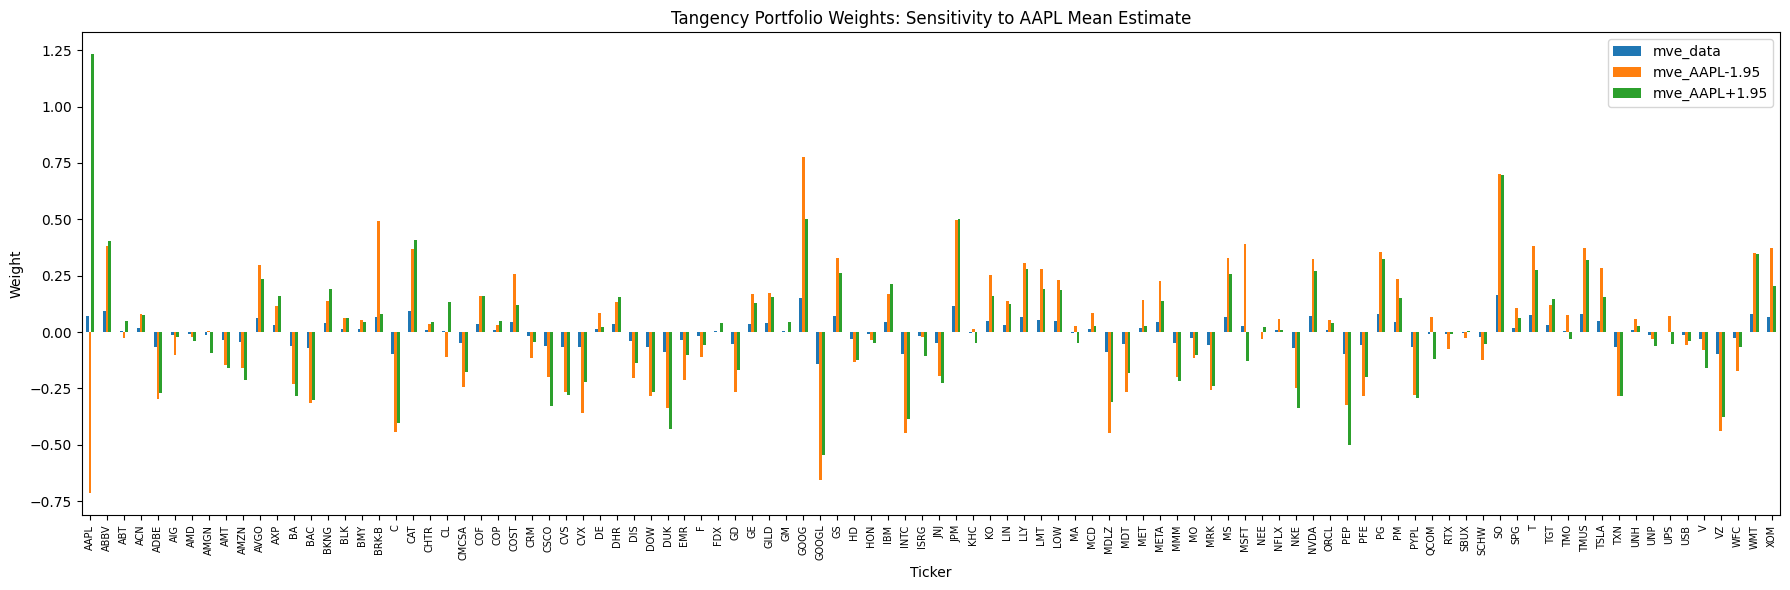

In [31]:
TICKER = "AAPL"

ERe_lower = ERe.copy()
ERe_upper = ERe.copy()
ERe_lower[TICKER] = ERe_ci.loc[TICKER, 'lower bound']
ERe_upper[TICKER] = ERe_ci.loc[TICKER, 'upper bound']

raw_lower = invCovRe @ ERe_lower
vol_lower = np.sqrt(12 * raw_lower @ CovRe @ raw_lower)
Weights[f'mve_{TICKER}-1.95'] = (0.10 / vol_lower) * raw_lower

raw_upper = invCovRe @ ERe_upper
vol_upper = np.sqrt(12 * raw_upper @ CovRe @ raw_upper)
Weights[f'mve_{TICKER}+1.95'] = (0.10 / vol_upper) * raw_upper

fig, ax = plt.subplots(figsize=(18, 6))
Weights.plot.bar(ax=ax)
ax.set_title(f'Tangency Portfolio Weights: Sensitivity to {TICKER} Mean Estimate')
ax.set_ylabel('Weight')
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

#### Discussion

1. **How much do the weights change?** Perturbing a single stock's expected return by the width of its 95% CI causes visible shifts in many weights across the portfolio — not just in the perturbed stock. With ~100 stocks the optimizer has more degrees of freedom than with 49 industries, so the swings can be even larger in relative terms.

2. **Which assets are impacted?** Stocks most correlated with AAPL (other mega-cap tech names) see the biggest changes, because the inverse covariance matrix propagates the change in one mean across all assets it is correlated with. Stocks with low correlation to AAPL move very little.

**8. Performance impact of estimation uncertainty**

Compute the in-sample annualized Sharpe Ratio for all three weight schemes using the **real** sample moments.

In [32]:
def compute_sr(weights, ERe, CovRe):
    port_mean = weights @ ERe
    port_vol = np.sqrt(weights @ CovRe @ weights)
    return port_mean / port_vol * np.sqrt(252)

sr_data = compute_sr(Weights['mve_data'].values, ERe.values, CovRe.values)
sr_lower = compute_sr(Weights[f'mve_{TICKER}-1.95'].values, ERe.values, CovRe.values)
sr_upper = compute_sr(Weights[f'mve_{TICKER}+1.95'].values, ERe.values, CovRe.values)

print(f"SR (mve_data):              {sr_data:.4f}")
print(f"SR (mve_{TICKER}-1.95):     {sr_lower:.4f}")
print(f"SR (mve_{TICKER}+1.95):     {sr_upper:.4f}")

SR (mve_data):              3.5295
SR (mve_AAPL-1.95):     3.2496
SR (mve_AAPL+1.95):     3.2958


#### Discussion

The perturbed portfolios have lower in-sample SRs than `mve_data`, since by construction `mve_data` is the SR-maximizing portfolio on the sample moments. Any deviation lowers in-sample SR; out-of-sample, the situation typically *reverses* — the optimized portfolio overfits the sample.

**9. Repeat the perturbation exercise for every stock**

For each stock, perturb its mean to the lower and upper bound of its CI, recompute weights and SR, then record the average relative SR change:

$$dSR[\text{asset}] = \tfrac{1}{2}\,\frac{SR(\text{asset}+1.95) + SR(\text{asset}-1.95) - 2\,SR(\text{data})}{SR(\text{data})}$$

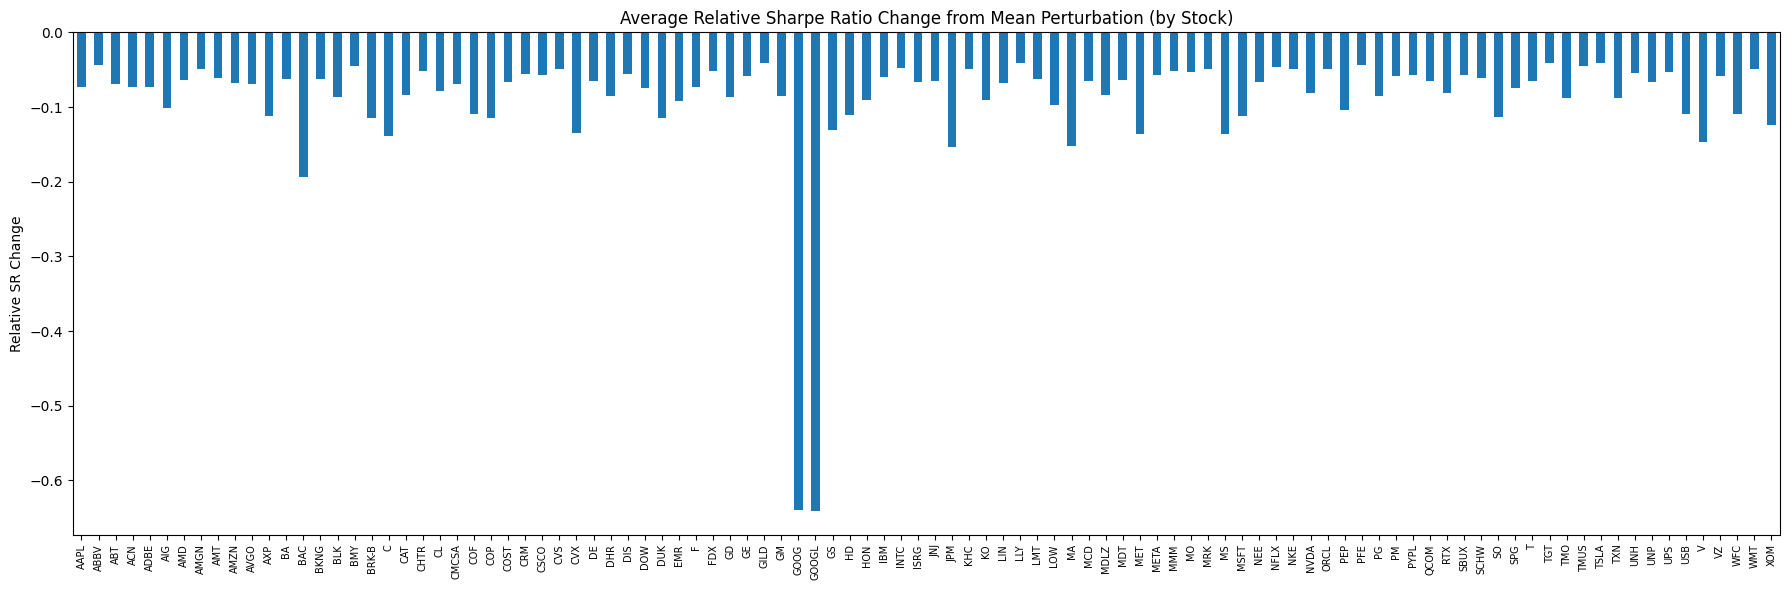

In [33]:
sr_changes = {}
sr_baseline = compute_sr(Weights['mve_data'].values, ERe.values, CovRe.values)

for asset in df.columns:
    ERe_lo = ERe.copy()
    ERe_lo[asset] = ERe_ci.loc[asset, 'lower bound']
    raw_lo = invCovRe @ ERe_lo.values
    vol_lo = np.sqrt(252 * raw_lo @ CovRe.values @ raw_lo)
    w_lo = (0.10 / vol_lo) * raw_lo
    sr_lo = compute_sr(w_lo, ERe.values, CovRe.values)

    ERe_up = ERe.copy()
    ERe_up[asset] = ERe_ci.loc[asset, 'upper bound']
    raw_up = invCovRe @ ERe_up.values
    vol_up = np.sqrt(12 * raw_up @ CovRe.values @ raw_up)
    w_up = (0.10 / vol_up) * raw_up
    sr_up = compute_sr(w_up, ERe.values, CovRe.values)

    sr_changes[asset] = 0.5 * ((sr_lo - sr_baseline) + (sr_up - sr_baseline)) / sr_baseline

dSR = pd.DataFrame.from_dict(sr_changes, orient='index', columns=['SR_change'])

fig, ax = plt.subplots(figsize=(18, 6))
dSR.plot.bar(ax=ax, legend=False)
ax.set_title('Average Relative Sharpe Ratio Change from Mean Perturbation (by Stock)')
ax.set_ylabel('Relative SR Change')
ax.axhline(0, color='black', linewidth=0.5)
ax.tick_params(axis='x', labelsize=7)
plt.tight_layout()
plt.show()

#### Discussion

Every perturbation reduces the in-sample SR (all bars are negative). The tangency portfolio built on ~100 individual stocks is **even more fragile** than the 49-industry version because (a) individual stocks have noisier mean estimates than diversified industry portfolios, and (b) a larger covariance matrix is harder to invert stably. This is exactly the setting where shrinkage / factor-model / equal-weight approaches dominate vanilla MVE out-of-sample.

**10. Monte Carlo, part 1 — one draw**

In [34]:
one_draw = np.random.multivariate_normal(ERe.values, CovRe.values)
print(f"Shape: {one_draw.shape}")
print(one_draw[:5])

Shape: (100,)
[0.03205262 0.00556996 0.02413402 0.03795628 0.01193569]


**11. Monte Carlo, part 2 — full sample of T months**

In [35]:
T = len(df)
simulated_sample = np.random.multivariate_normal(ERe.values, CovRe.values, size=T)
print(f"Shape: {simulated_sample.shape}")

Shape: (1455, 100)


**12. Monte Carlo, part 3 — Sharpe Ratio of `mve_data` on a simulated sample**

In [36]:
simulated_returns = np.random.multivariate_normal(ERe.values, CovRe.values, size=T)
w_mve = Weights['mve_data'].values

simulated_port_returns = simulated_returns @ w_mve
sim_sr = simulated_port_returns.mean() / simulated_port_returns.std() * np.sqrt(252)
print(f"Simulated SR: {sim_sr:.4f}")

Simulated SR: 3.5593


**13. Monte Carlo, part 4 — 1000 simulations and the SR distribution**

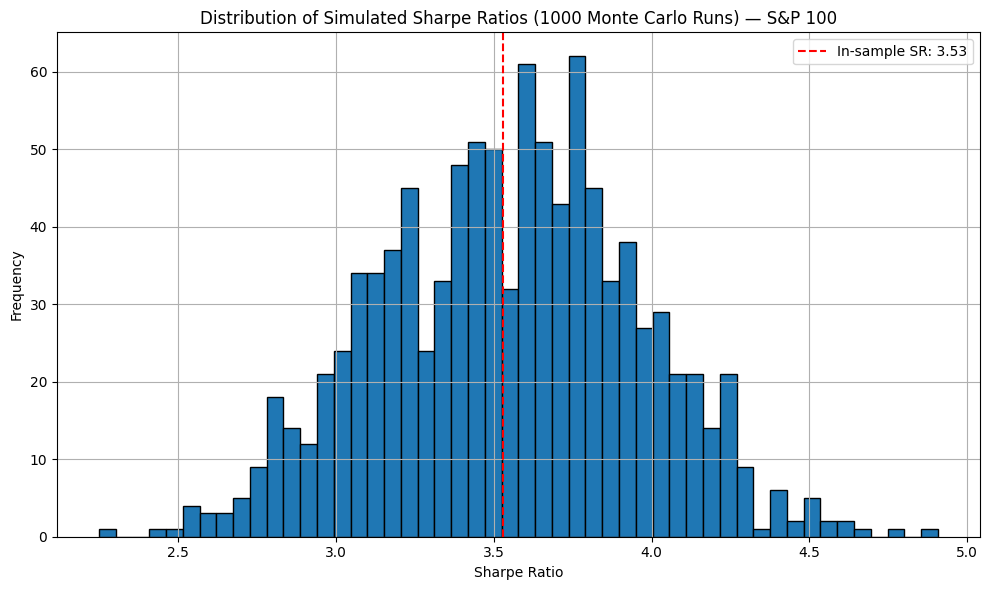

Mean MC SR:   3.5476
Std MC SR:    0.4107
In-sample SR: 3.5295


In [37]:
mc_sharpes = []
for _ in range(1000):
    sim_ret = np.random.multivariate_normal(ERe.values, CovRe.values, size=T)
    sim_port = sim_ret @ w_mve
    sr = sim_port.mean() / sim_port.std() * np.sqrt(252)
    mc_sharpes.append(sr)

MC = pd.DataFrame(mc_sharpes, columns=['SR'])

fig, ax = plt.subplots(figsize=(10, 6))
MC.hist(bins=50, ax=ax, edgecolor='black')
ax.set_title('Distribution of Simulated Sharpe Ratios (1000 Monte Carlo Runs) — S&P 100')
ax.set_xlabel('Sharpe Ratio')
ax.set_ylabel('Frequency')
ax.axvline(x=sr_baseline, color='red', linestyle='--', label=f'In-sample SR: {sr_baseline:.2f}')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean MC SR:   {MC['SR'].mean():.4f}")
print(f"Std MC SR:    {MC['SR'].std():.4f}")
print(f"In-sample SR: {sr_baseline:.4f}")

#### Discussion

With ~100 stocks the in-sample SR is typically much higher than with 49 industries (the optimizer has more assets to exploit), but the Monte Carlo distribution is also **wider**: many simulations land far below the in-sample value. This gap between in-sample and simulated SR is the signature of estimation risk — and it grows with the number of assets relative to the sample size.

**14. Why an investor should care**

The same lessons as the industry-portfolio version apply, and they are *sharper* with individual S&P 100 stocks:

1. **The tangency portfolio is theoretically optimal but practically fragile.** Small perturbations of a single stock's expected return within its 95% CI move many weights and degrade realized performance.

2. **Expected returns of individual stocks are very noisy.** Most CIs around mean excess returns contain zero. The inverse covariance matrix amplifies that noise.

3. **In-sample SRs are overly optimistic.** The Monte Carlo distribution is centered well below the in-sample SR — even when the simulation uses the *true* assumed moments, sampling variation alone produces a wide spread of realized Sharpe Ratios.

4. **Practical takeaway:** use shrinkage on the mean and the covariance, impose weight constraints, work with factor models, or fall back on equal-weight / minimum-variance portfolios that don't depend on expected return estimates.